In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
# Define dtypes for columns that might cause issues
dtypes = {
    'CompetitionDistance': 'float32',
    'CompetitionOpenSinceMonth': 'float32',
    'CompetitionOpenSinceYear': 'float32',
    'Promo2SinceWeek': 'float32',
    'Promo2SinceYear': 'float32',
    'StateHoliday': 'category',
    'DayOfWeek': 'int8',
    'Month': 'int8',
    'Year': 'int16'
}

In [46]:
train = pd.read_csv(r'C:\Users\Антон\OneDrive\Документы\Machine Learning\Projects\linear_regression\data\rossmann-store-sales\train.csv', 
                    parse_dates=['Date'], dtype=dtypes)
store = pd.read_csv(r"C:\Users\Антон\OneDrive\Документы\Machine Learning\Projects\linear_regression\data\rossmann-store-sales\store.csv",
                   dtype=dtypes)
test = pd.read_csv(r"C:\Users\Антон\OneDrive\Документы\Machine Learning\Projects\linear_regression\data\rossmann-store-sales\test.csv", 
                   parse_dates=['Date'],dtype=dtypes)

In [47]:
# merging datasets
train = train.merge(store, on='Store', how='left')
test = test.merge(store, on='Store', how='left')

In [48]:
train.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


Most of the fields are self-explanatory. The following are descriptions for those that aren't.

- Id - an Id that represents a (Store, Date) duple within the test set
- Store - a unique Id for each store
- Sales - the turnover for any given day (this is what you are predicting)
- Customers - the number of customers on a given day
- Open - an indicator for whether the store was open: 0 = closed, 1 = open
- StateHoliday - indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays. Note that all schools are closed on public holidays and weekends. a = public holiday, b = Easter holiday, c = Christmas, 0 = None
- SchoolHoliday - indicates if the (Store, Date) was affected by the closure of public schools
- StoreType - differentiates between 4 different store models: a, b, c, d
- Assortment - describes an assortment level: a = basic, b = extra, c = extended
- CompetitionDistance - distance in meters to the nearest competitor store
- CompetitionOpenSince[Month/Year] - gives the approximate year and month of the time the nearest competitor was opened
- Promo - indicates whether a store is running a promo on that day
- Promo2 - Promo2 is a continuing and consecutive promotion for some stores: 0 = store is not participating, 1 = store is participating
- Promo2Since[Year/Week] - describes the year and calendar week when the store started participating in Promo2
- PromoInterval - describes the consecutive intervals Promo2 is started, naming the months the promotion is started anew. E.g. "Feb,May,Aug,Nov" means each round starts in February, May, August, November of any given year for that storer for that store

### Data Preprocessing

#### Handle missing values

In [49]:
# Check for missing values
print(train.isnull().sum())

# Impute missing values (example: fill with median for 'CompetitionDistance')
# train['CompetitionDistance'].fillna(train['CompetitionDistance'].median(), inplace=True)

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64


In [50]:
train['CompetitionDistance'].fillna(train['CompetitionDistance'].median(), inplace=True)

C:\Users\Антон\AppData\Local\Temp\ipykernel_31192\1237283367.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['CompetitionDistance'].fillna(train['CompetitionDistance'].median(), inplace=True)


#### Feature Engineering

##### Extract time-based features

In [51]:
train['Year'] = train['Date'].dt.year
train['Month'] = train['Date'].dt.month
train['Day'] = train['Date'].dt.day
train['DayOfWeek'] = train['Date'].dt.dayofweek
train['IsPromo'] = train['Promo'].astype(int)

##### Create lag features

In [52]:
train['Sales_Lag1'] = train.groupby('Store')['Sales'].shift(1)

### EDA

#### Sales over time

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length

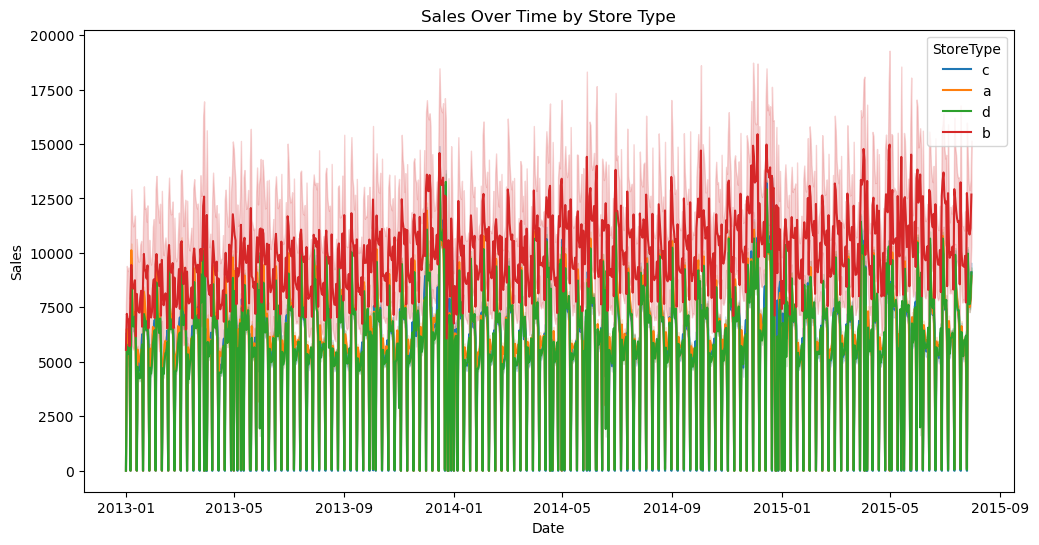

In [53]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=train, x='Date', y='Sales', hue='StoreType')
plt.title('Sales Over Time by Store Type')
plt.show()

##### Key Observations:
1. Store types:
   - store types d and c consistently show the highest sales across all dates
2. Seasonality:
   - New year Spikes: Clear spikes around January 1st (2014, 2015)
3. Trends:
   - No clear upward/downward trend in overall sales over 2013-2015 period
   - Volatility: Sales fluctuate significantly
4. Outliers:
   - Occasional extreme spikes (e.g., mid-2014, 2015) suggest promotions, special events, or data errors.

#### Correlation heatmap

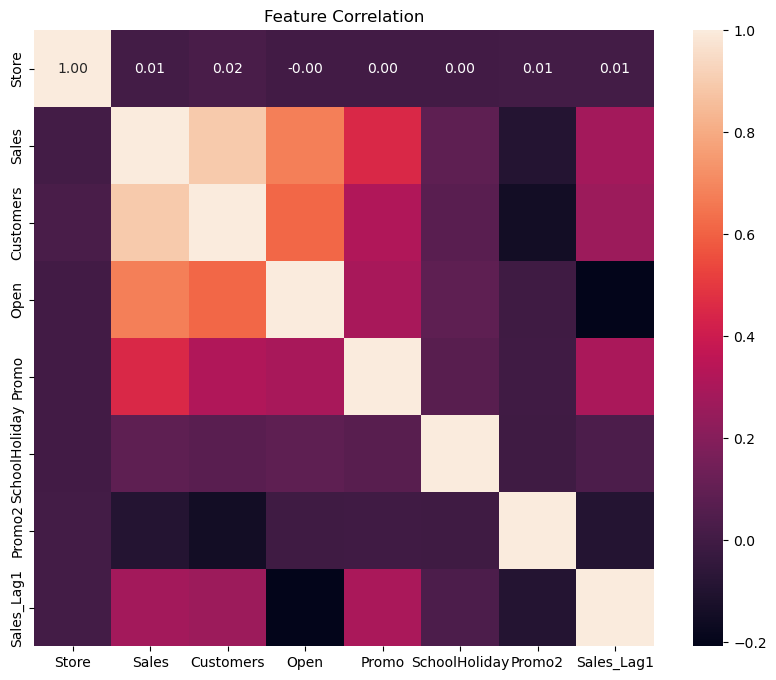

In [54]:
# Select only numeric columns for correlation
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns
corr = train[numeric_cols].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title('Feature Correlation')
plt.show()

In [55]:
corr

,Store,Sales,Customers,Open,Promo,SchoolHoliday,Promo2,Sales_Lag1
Store,1.000000,0.005126,0.024325,-0.000047,0.000058,0.000641,0.008488,0.005135
Sales,0.005126,1.000000,0.894711,0.678472,0.452345,0.085124,-0.091040,0.278360
Customers,0.024325,0.894711,1.000000,0.616768,0.316169,0.071568,-0.150159,0.261988
Open,-0.000047,0.678472,0.616768,1.000000,0.295042,0.086171,-0.008309,-0.208110
Promo,0.000058,0.452345,0.316169,0.295042,1.000000,0.067483,-0.000983,0.296861
SchoolHoliday,0.000641,0.085124,0.071568,0.086171,0.067483,1.000000,-0.006909,0.036842
Promo2,0.008488,-0.091040,-0.150159,-0.008309,-0.000983,-0.006909,1.000000,-0.091145
Sales_Lag1,0.005135,0.278360,0.261988,-0.208110,0.296861,0.036842,-0.091145,1.000000


##### Key Observations:
1. Strongest Positive Correlations:
   - Customer - Sales (0.89): The number of customers is highly correlated with sales. This is expected since more customers mean more sales
   - Open - Sales (0.68) Which kind of crazy
   - Open - Customers (0.61) kind of crazy too
   - Promo - Sales (0.45) - promotions directly boost sales.make sense
   - Promo - customers (0.32) - promotions attract customers, which alighns with retail logic
2. Weak or No Correlations:
   - Store - Sales (0.00) The store itself has no correlation with sales
   - SchoolHoliday - Sales(0.09)
3. Lag Feature:
   - The lag feature(previous day sales) has a weak correlation, suggestin that sales not strongly depend on the previous day`s performance

### Train-Test Split 

Using time-based splitting to avoid data leakage

In [56]:
train_data = train[train['Date'] < '2015-07-01']
val_data = train[train['Date'] >= '2015-07-01']

### Model training (Linear Regression)

#### feature selection

In [57]:
features = ['DayOfWeek', 'IsPromo', 'Year', 'Month', 'CompetitionDistance']
X_train = train_data[features]
y_train = train_data['Sales']

#### model training

In [58]:
train_data.columns.tolist()

['Store',
 'DayOfWeek',
 'Date',
 'Sales',
 'Customers',
 'Open',
 'Promo',
 'StateHoliday',
 'SchoolHoliday',
 'StoreType',
 'Assortment',
 'CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'CompetitionOpenSinceYear',
 'Promo2',
 'Promo2SinceWeek',
 'Promo2SinceYear',
 'PromoInterval',
 'Year',
 'Month',
 'Day',
 'IsPromo',
 'Sales_Lag1']

In [59]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Model Evaluation

#### Predict on validation data

In [60]:
X_val = val_data[features]
y_val = val_data['Sales']
y_pred = model.predict(X_val)

#### Calculate Metrics

In [61]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = mean_squared_error(y_val, y_pred, squared=False)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

RMSE: 2909.21
MAE: 2198.13
R²: 0.35


### Feature Importance

In [62]:
importance = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})
importance = importance.sort_values(by='Coefficient', ascending=False)
print(importance)

               Feature  Coefficient
1              IsPromo  2537.084070
2                 Year   160.108671
3                Month    68.860584
4  CompetitionDistance    -0.010264
0            DayOfWeek  -645.993878


##### Interpretation:
- IsPromo: 2537.08 (strong positive impact)
- Year: 160.11 (positive but weak)
- Month: 68.86 (positive but weak)
- CompetitionDistance: -0.01 (almost no impact)
- DayOfWeek: -645.99 (negative impact, which is kind of counterintuitive)

### feature engineering

In [63]:
train['DayOfWeek'].unique()

array([4, 3, 2, 1, 0, 6, 5])

DayOfWeek is likely encoded as 0=Monday, 1=Tuesday, ..., 6=Sunday.  
Sales should be higher on weekends, but the negative coefficient suggests the model sees lower sales for higher DayOfWeek values

Let`s decode to reflect it:

In [64]:
train['IsWeekend'] = (train['DayOfWeek'] >= 5).astype(int)

Next let`s add rolling features to capture short-term trends(7 and 30 day)

In [65]:
# 7-day rolling average of sales
train['Sales_Rolling7'] = train.groupby('Store')['Sales'].transform(lambda x: x.rolling(7).mean())

# 30-day rolling average
train['Sales_Rolling30'] = train.groupby('Store')['Sales'].transform(lambda x: x.rolling(30).mean())

Add interactions to capture synergies between features

In [66]:
# Interaction: Promo * Weekend
train['Promo_Weekend'] = train['IsPromo'] * train['IsWeekend']

# Interaction: Promo * CompetitionDistance (if relevant)
train['Promo_Competition'] = train['IsPromo'] * train['CompetitionDistance']

adding holiday flags



In [67]:
# Add a binary flag for major holidays
train['IsHoliday'] = train['Date'].isin(['2013-12-25', '2014-12-25', '2015-12-25']).astype(int)

C:\Users\Антон\AppData\Local\Temp\ipykernel_31192\3830761126.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  train['IsHoliday'] = train['Date'].isin(['2013-12-25', '2014-12-25', '2015-12-25']).astype(int)


In [68]:
# Lag 1 (previous day)
train['Sales_Lag1'] = train.groupby('Store')['Sales'].shift(1)

# Lag 7 (same day last week)
train['Sales_Lag7'] = train.groupby('Store')['Sales'].shift(7)

#### Retraining the model

In [72]:
train.columns.tolist()

['Store',
 'DayOfWeek',
 'Date',
 'Sales',
 'Customers',
 'Open',
 'Promo',
 'StateHoliday',
 'SchoolHoliday',
 'StoreType',
 'Assortment',
 'CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'CompetitionOpenSinceYear',
 'Promo2',
 'Promo2SinceWeek',
 'Promo2SinceYear',
 'PromoInterval',
 'Year',
 'Month',
 'Day',
 'IsPromo',
 'Sales_Lag1',
 'IsWeekend',
 'Sales_Rolling7',
 'Sales_Rolling30',
 'Promo_Weekend',
 'Promo_Competition',
 'IsHoliday',
 'Sales_Lag7']

In [75]:
# Drop rows with NaN after adding lag/rolling features
train_data = train[train['Date'] < '2015-07-01']
val_data = train[train['Date'] >= '2015-07-01']
train_data = train_data.dropna()
val_data = val_data.dropna()
features = ['IsPromo','IsWeekend', 'Year', 'Month', 'Sales_Rolling7','Sales_Rolling30','Promo_Weekend', 
            'IsHoliday','Sales_Lag1','Sales_Lag7']

In [76]:
X_train = train_data[features]
y_train = train_data['Sales']

In [77]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [78]:
X_val = val_data[features]
y_val = val_data['Sales']
y_pred = model.predict(X_val)

In [79]:
rmse = mean_squared_error(y_val, y_pred, squared=False)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

RMSE: 1134.09
MAE: 905.26
R²: 0.73


#### Results

RMSE dropped from 2909 with initial model to 1134, MAE from 2198 to 905, and R² increased from 0.35 to 0.73. This is significant improvement. RMSE reduced by 61%, MAE - by 59%, R² doubled. That tells us that our feature engineering steps were highly effective.(adding rolling features, interaction terms, holiday flags)